In [1]:
from pathlib import Path

from loss_PDE.bout_dump import BOUTHESELInfo
from loss_PDE.bout_phys import BOUTHESELPhys

root = Path.cwd().parent / 'simulatorer' / 'BOUT' / 'BOUT-HESEL' / 'data'
info = BOUTHESELInfo(root)
phys = BOUTHESELPhys(info)

In [2]:
# for (section, name), value in info.settings.items():
#     print(f'{section},{name} = {value}')

# for field, value in info.data.__dict__.items():
#     print(f'{field} = {value.shape}')

# for field, value in info.parameters.__dict__.items():
#     print(f'{field} = {value}')

# for name, foo in info.functions.__dict__.items():
#     print(f'{name} = {foo}')

3D fields: ['lnn', 'lnpe', 'lnpi', 'phi', 'vort']
2D fields: ['init_n', 'init_pe', 'init_pi', 'sigma_open', 'sigma_closed', 'sigma_force', 'B', 'dx', 'lconn']
Skipped scalar fields: ['dz', 'Bt', 'q', 'Te0', 'Ti0', 'n0', 'Rmajor', 'Rminor', 'A', 'Z', 'Mach', 'x_lcfs', 'x_wall', 'force_time', 'floor_time', 'floor_n', 'floor_pe', 'floor_pi', 'B0', 'oci', 'rhoe', 'rhos', 'nuei', 'nuii', 'nuee', 'neoclass_correction_factor', 'lblob']


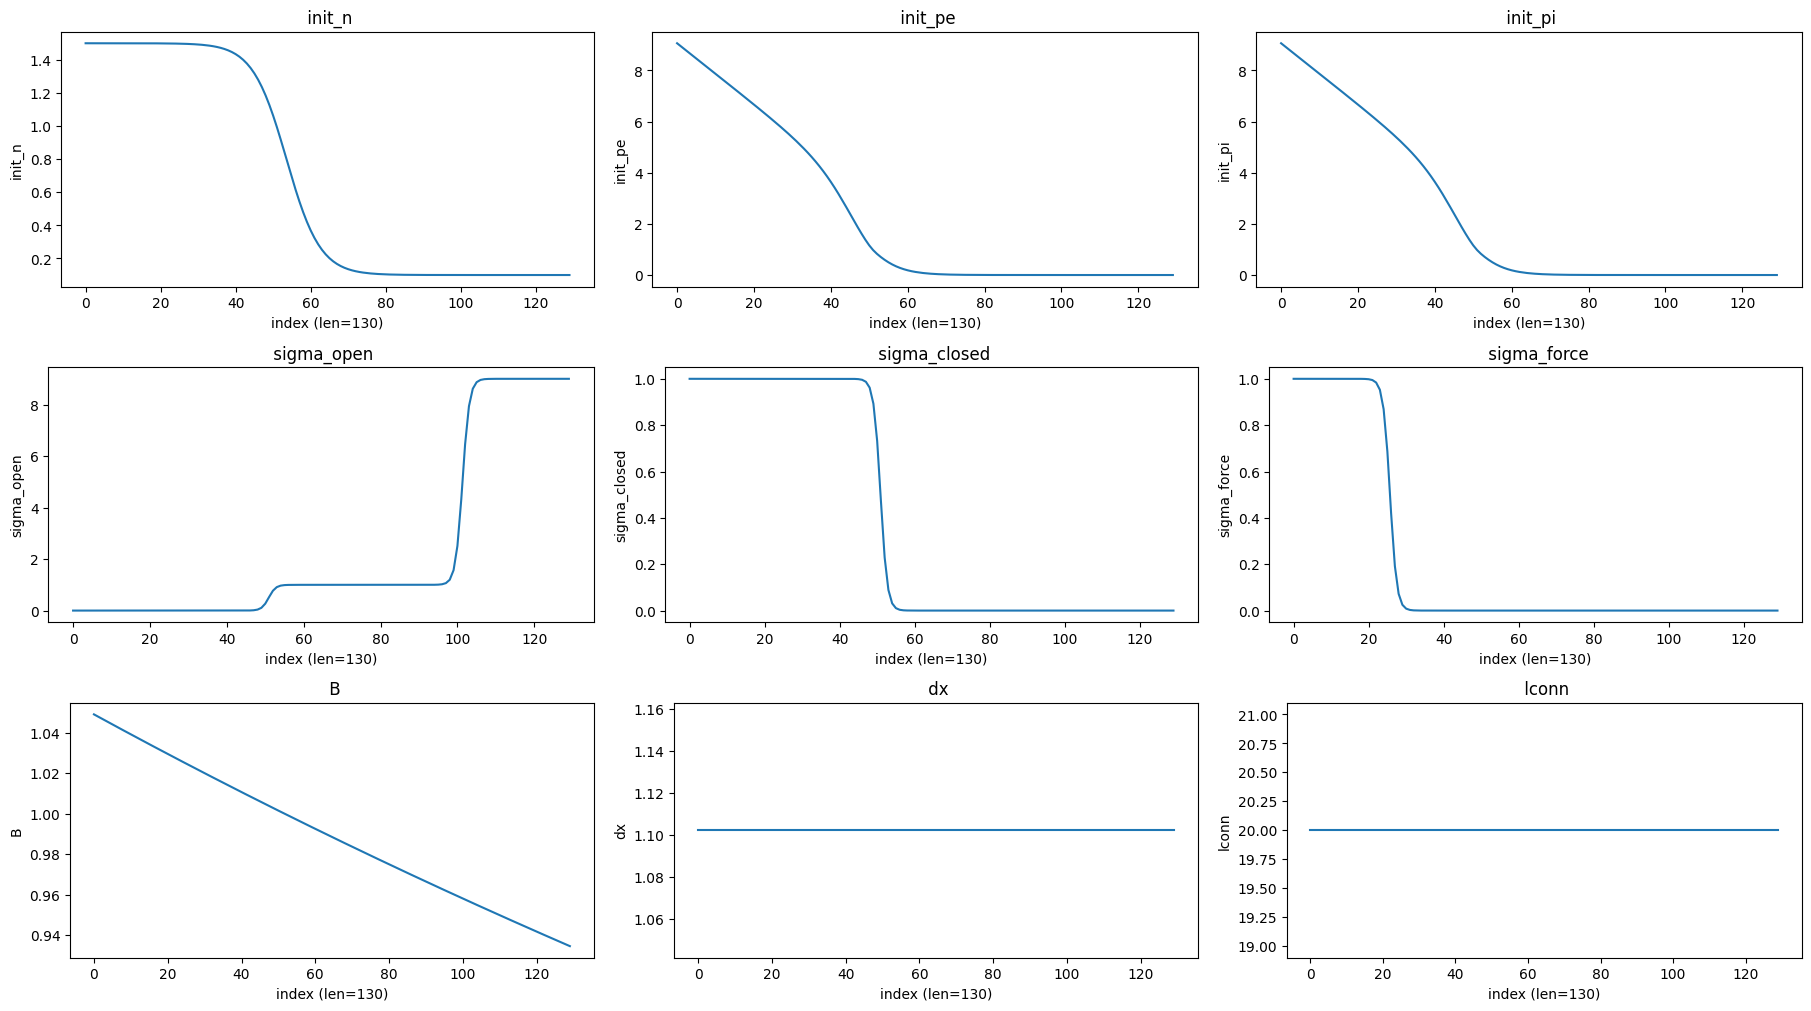

In [3]:
from math import ceil
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

three_d_fields = []
two_d_fields = []
scalar_fields = []
time_array = info.data.t_array.detach().cpu().numpy()
for name, arr in info.data.__dict__.items():
    if arr is None or name == 't_array':
        continue
    if arr.ndim == 3:
        three_d_fields.append((name, arr))
    elif arr.ndim == 1:
        two_d_fields.append((name, arr))
    elif arr.ndim == 0:
        scalar_fields.append(name)

print('3D fields:', [name for name, _ in three_d_fields])
print('2D fields:', [name for name, _ in two_d_fields])
print('Skipped scalar fields:', scalar_fields)

def make_grid(n_items, ncols):
    return ceil(n_items / ncols), ncols

def axis_label(name, length):
    return f'{name} (len={length})'

def plot_3d_frame(time_index):
    time_value = float(time_array[time_index])
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(three_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(three_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        frame = arr[time_index].detach().cpu().numpy().T
        im = ax.imshow(frame, cmap='viridis', interpolation='nearest', vmin=float(arr.min().item()), vmax=float(arr.max().item()))
        ax.set_title(f'{name} @ t={time_value:.4g}')
        ax.set_xlabel(axis_label('x', arr.shape[1]))
        ax.set_ylabel(axis_label('z', arr.shape[2]))
        fig.colorbar(im, ax=ax, shrink=0.8)

    for subfig in subfigs[len(three_d_fields):]:
        subfig.set_visible(False)

    return fig

def plot_two_d_fields():
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    nrows, ncols = make_grid(len(two_d_fields), 3)
    subfigs = np.asarray(fig.subfigures(nrows, ncols, squeeze=False)).ravel()

    for slot, (name, arr) in enumerate(two_d_fields):
        subfig = subfigs[slot]
        ax = subfig.subplots()
        values = arr.detach().cpu().numpy()
        ax.plot(np.arange(values.shape[0]), values, linewidth=1.5)
        ax.set_title(f" {name}")
        ax.set_xlabel(axis_label('index', values.shape[0]))
        ax.set_ylabel(name)

    for subfig in subfigs[len(two_d_fields):]:
        subfig.set_visible(False)

    return fig


output_3d = widgets.Output()
slider = widgets.IntSlider(
    min=0,
    max=len(time_array) - 1,
    step=1,
    value=0,
    description='t',
    continuous_update=False,
)

def render_3d(_change=None):
    _ = _change
    with output_3d:
        output_3d.clear_output(wait=True)
        fig = plot_3d_frame(slider.value)
        display(fig)
        plt.close(fig)

slider.observe(render_3d, names='value')
render_3d()
display(widgets.VBox([slider, output_3d]))

fig = None
if two_d_fields:
    fig = plot_two_d_fields()
    display(fig)
if fig is not None:
    plt.close(fig)



Axis lengths: t=875, x=130, z=128
Sample sizes: len(t)=10000, len(x)=10000, len(z)=10000


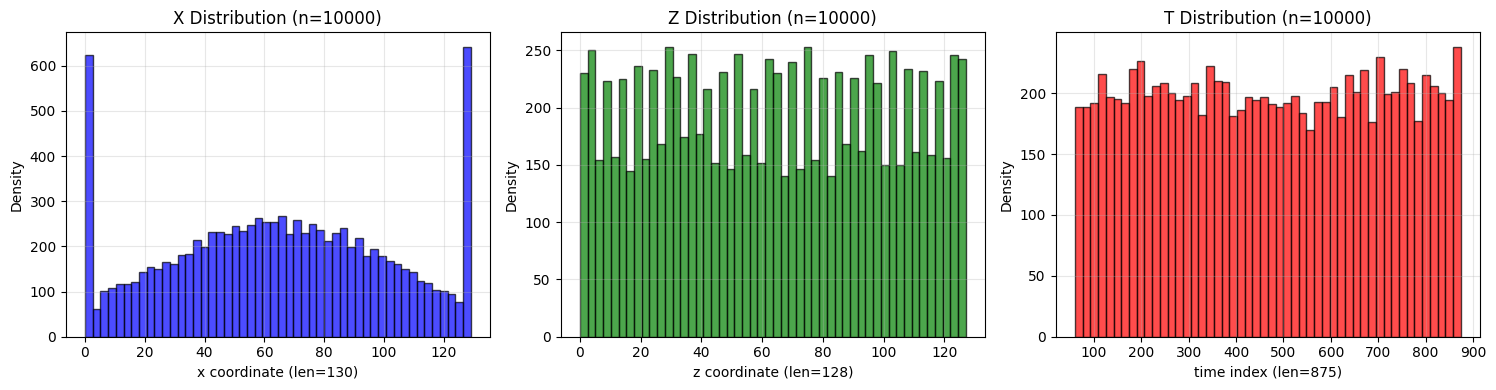

In [4]:
import torch

# Inline collocation_points function
def collocation_points(info, num_points):
    nt, nx, nz = info.data.lnn.shape
    t = torch.randint(60, nt, (num_points,))
    z = torch.randint(0, nz, (num_points,))
    # x is normal distributed around x/2 with std 20, and clamped to [0, nz]
    x = torch.randn(num_points) * 40 + nx / 2
    x = torch.clamp(x, 0, nx - 1)
    return t, x, z

# Generate collocation points
num_coll_points = 10000
t_coll, x_coll, z_coll = collocation_points(info, num_coll_points)

# Convert to numpy for plotting
x_coll_np = x_coll.numpy()
z_coll_np = z_coll.numpy()
t_coll_np = t_coll.numpy()

print(f"Axis lengths: t={info.data.lnn.shape[0]}, x={info.data.lnn.shape[1]}, z={info.data.lnn.shape[2]}")
print(f"Sample sizes: len(t)={len(t_coll_np)}, len(x)={len(x_coll_np)}, len(z)={len(z_coll_np)}")

# Plot 1: Three 1D distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# X distribution
axes[0].hist(x_coll_np, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel(f'x coordinate (len={info.data.lnn.shape[1]})')
axes[0].set_ylabel('Density')
axes[0].set_title(f'X Distribution (n={num_coll_points})')
axes[0].grid(alpha=0.3)

# Z distribution
axes[1].hist(z_coll_np, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel(f'z coordinate (len={info.data.lnn.shape[2]})')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Z Distribution (n={num_coll_points})')
axes[1].grid(alpha=0.3)

# T distribution
axes[2].hist(t_coll_np, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[2].set_xlabel(f'time index (len={info.data.lnn.shape[0]})')
axes[2].set_ylabel('Density')
axes[2].set_title(f'T Distribution (n={num_coll_points})')
axes[2].grid(alpha=0.3)

plt.tight_layout()
display(fig)
plt.close(fig)

# Plot 2: Interactive 2D plot with time slider
output_2d = widgets.Output()
t_slider = widgets.IntSlider(
    min=int(t_coll_np.min()),
    max=int(t_coll_np.max()),
    step=1,
    value=int(t_coll_np.min()),
    description='Time index:',
    continuous_update=False,
)

def plot_2d_at_time(t_val):
    # Filter points for this time index (with tolerance)
    mask = np.abs(t_coll_np - t_val) < 0.5
    x_filtered = x_coll_np[mask]
    z_filtered = z_coll_np[mask]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x_filtered, z_filtered, s=20, alpha=0.6, c='blue', edgecolors='navy')
    ax.set_xlabel(f'x (len={info.data.lnn.shape[1]})')
    ax.set_ylabel(f'z (len={info.data.lnn.shape[2]})')
    ax.set_xlim(-1, info.data.lnn.shape[1])
    ax.set_ylim(-1, info.data.lnn.shape[2])
    ax.set_title(f'Collocation Points at t={t_val} (n={len(x_filtered)} points)')
    ax.grid(alpha=0.3)
    return fig

def render_2d(_change=None):
    _ = _change
    with output_2d:
        output_2d.clear_output(wait=True)
        fig = plot_2d_at_time(t_slider.value)
        display(fig)
        plt.close(fig)

t_slider.observe(render_2d, names='value')
render_2d()
display(widgets.VBox([t_slider, output_2d]))

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

selected_fields = ['lnn', 'lnpe', 'lnpi', 'phi']
field_arrays = []
for field_name in selected_fields:
    if not hasattr(info.data, field_name):
        raise AttributeError(f'Missing field: {field_name}')
    field_arrays.append((field_name, getattr(info.data, field_name)))

max_time_index = min(309, len(time_array) - 1)
coll_t = t_coll_np.astype(int)
coll_x = np.clip(np.rint(x_coll_np).astype(int), 0, info.data.lnn.shape[1] - 1)
coll_z = z_coll_np.astype(int)

def plot_fields_with_collocation(time_index):
    time_index = int(np.clip(time_index, 0, max_time_index))
    time_value = float(time_array[time_index])
    mask = coll_t == time_index
    x_points = coll_x[mask]
    z_points = coll_z[mask]

    fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
    axes = axes.ravel()

    for ax, (field_name, arr) in zip(axes, field_arrays):
        frame = arr[time_index].detach().cpu().numpy().T
        im = ax.imshow(
            frame,
            cmap='viridis',
            interpolation='nearest',
            vmin=float(arr.min().item()),
            vmax=float(arr.max().item()),
            origin='lower',
            aspect='auto',
        )
        if len(x_points) > 0:
            ax.scatter(x_points, z_points, s=18, c='red', alpha=0.85, edgecolors='black', linewidths=0.25, marker='o', zorder=5)
        ax.set_title(f'{field_name} @ t={time_value:.4g}')
        ax.set_xlabel(f'x (len={arr.shape[1]})')
        ax.set_ylabel(f'z (len={arr.shape[2]})')
        fig.colorbar(im, ax=ax, shrink=0.8)

    return fig

output_collocation = widgets.Output()
time_slider = widgets.IntSlider(
    min=0,
    max=max_time_index,
    step=1,
    value=0,
    description='t',
    continuous_update=False,
)

def render_collocation_plot(_change=None):
    _ = _change
    with output_collocation:
        output_collocation.clear_output(wait=True)
        fig = plot_fields_with_collocation(time_slider.value)
        display(fig)
        plt.close(fig)

time_slider.observe(render_collocation_plot, names='value')
render_collocation_plot()
display(widgets.VBox([time_slider, output_collocation]))

In [6]:
# Load trained PINN from latest checkpoint and render 4x4 comparison with time slider
import torch
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from util.model import PINN
from util.structure import NN_STRUCTURE

field_names = ['lnn', 'lnpe', 'lnpi', 'phi']
eq_key_for_field = {'lnn': 'eq_lnn', 'lnpe': 'eq_lnpe', 'lnpi': 'eq_lnpi', 'phi': 'eq_vort'}


def latest_checkpoint() -> Path:
    search_roots = [Path.cwd() / 'wandb' / 'latest-run', Path.cwd() / 'wandb', Path.cwd() / 'data']
    checkpoints = sorted({p for root in search_roots if root.exists() for p in root.rglob('*.pt')})
    if not checkpoints:
        raise FileNotFoundError('No .pt checkpoint found in wandb/latest-run, wandb, or data.')
    return checkpoints[-1]


ckpt = torch.load(latest_checkpoint(), map_location='cpu')
model = PINN(NN_STRUCTURE)
state_dict = ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state_dict)
model.eval()

if isinstance(ckpt, dict) and 'output_scaling' in ckpt:
    scaling = ckpt['output_scaling']
    means = torch.tensor([scaling[name]['mean'] for name in field_names], dtype=torch.float32)
    stds = torch.tensor([scaling[name]['std'] for name in field_names], dtype=torch.float32)
    standardization = type(info.standardized)(mean=means, std=stds)
else:
    standardization = type(info.standardized)(mean=info.standardized.mean, std=info.standardized.std)

nt, _, _ = info.data.lnn.shape
fields = {name: torch.as_tensor(getattr(info.data, name), dtype=torch.float32) for name in field_names}
padded = {name: F.pad(arr, (1, 1, 1, 1), mode='replicate') for name, arr in fields.items()}

num_x = padded[field_names[0]].shape[1]
num_z = padded[field_names[0]].shape[2]
centers = [(x, z) for x in range(1, num_x - 1) for z in range(1, num_z - 1)]
N = len(centers)
centers_x = torch.tensor([x for x, _ in centers], dtype=torch.float32).view(N, 1)
centers_z = torch.tensor([z for _, z in centers], dtype=torch.float32).view(N, 1)

batch_size_pred = 4096
batch_size_eq = 1024


def build_inputs_for_t(t_idx: int):
    if t_idx < 2 or t_idx >= nt:
        raise ValueError(f't_idx {t_idx} out of valid range [2, {nt - 1}].')

    t0, t1 = t_idx - 2, t_idx - 1
    inputs = torch.empty((N, 2, len(field_names), 3, 3), dtype=torch.float32)
    for i, (cx, cz) in enumerate(centers):
        sx, sz = slice(cx - 1, cx + 2), slice(cz - 1, cz + 2)
        for j, name in enumerate(field_names):
            inputs[i, 0, j] = padded[name][t0, sx, sz]
            inputs[i, 1, j] = padded[name][t1, sx, sz]

    t_value = float(info.t_line[t_idx].item())
    t_tensor = torch.full((N, 1), t_value, dtype=torch.float32)
    return inputs, t_tensor


def scatter_flat_to_image(flat: torch.Tensor) -> torch.Tensor:
    img = torch.zeros((num_x - 2, num_z - 2), dtype=torch.float32)
    for idx, (cx, cz) in enumerate(centers):
        img[cx - 1, cz - 1] = flat[idx]
    return img


def predict_all_fields_and_eq(t_idx: int):
    inputs, t_tensor = build_inputs_for_t(t_idx)

    # predicted fields
    pred_flat = {name: [] for name in field_names}
    with torch.no_grad():
        for start in range(0, N, batch_size_pred):
            end = min(start + batch_size_pred, N)
            out = model.forward(
                standardization,
                centers_x[start:end],
                centers_z[start:end],
                t_tensor[start:end],
                inputs[start:end],
            )
            for name in field_names:
                pred_flat[name].append(out[name].detach().cpu().squeeze(-1))
    pred_flat = {name: torch.cat(parts, dim=0) for name, parts in pred_flat.items()}
    pred_imgs = {name: scatter_flat_to_image(pred_flat[name]) for name in field_names}

    # absolute equation residual images
    eq_flat = {k: [] for k in ('eq_lnn', 'eq_lnpe', 'eq_lnpi', 'eq_vort')}
    for start in range(0, N, batch_size_eq):
        end = min(start + batch_size_eq, N)

        x_b = centers_x[start:end].clone().detach().requires_grad_(True)
        z_b = centers_z[start:end].clone().detach().requires_grad_(True)
        t_b = t_tensor[start:end].clone().detach().requires_grad_(True)
        inp_b = inputs[start:end]

        state = model.forward(standardization, x_b, z_b, t_b, inp_b)
        eq = phys.eq_res(state, x_b, z_b, t_b)

        for k in eq_flat:
            eq_flat[k].append(eq[k].detach().abs().cpu().squeeze(-1))

    eq_flat = {k: torch.cat(parts, dim=0) for k, parts in eq_flat.items()}
    eq_imgs = {
        'lnn': scatter_flat_to_image(eq_flat['eq_lnn']),
        'lnpe': scatter_flat_to_image(eq_flat['eq_lnpe']),
        'lnpi': scatter_flat_to_image(eq_flat['eq_lnpi']),
        'phi': scatter_flat_to_image(eq_flat['eq_vort']),
    }

    return pred_imgs, eq_imgs

        

def draw_field_row(ax_row, name: str, eq_name: str, t_idx: int, pred: torch.Tensor, eq_abs: torch.Tensor):
    target = fields[name][t_idx].detach().cpu()
    abs_err = torch.abs(pred - target)

    vmin = float(min(target.min().item(), pred.min().item()))
    vmax = float(max(target.max().item(), pred.max().item()))
    err_max = float(abs_err.max().item()) if abs_err.numel() else 0.0
    eq_max = float(eq_abs.max().item()) if eq_abs.numel() else 0.0

    im0 = ax_row[0].imshow(target.T.numpy(), cmap='viridis', origin='lower', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax_row[0].set_title(f'{name} - Target @ t_idx={t_idx}')
    plt.colorbar(im0, ax=ax_row[0], shrink=0.8)

    im1 = ax_row[1].imshow(pred.T.numpy(), cmap='viridis', origin='lower', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax_row[1].set_title('Predicted')
    plt.colorbar(im1, ax=ax_row[1], shrink=0.8)

    im2 = ax_row[2].imshow(abs_err.T.numpy(), cmap='inferno', origin='lower', vmin=0.0, vmax=err_max, interpolation='nearest')
    ax_row[2].set_title('Absolute error |pred - target|')
    plt.colorbar(im2, ax=ax_row[2], shrink=0.8)

    im3 = ax_row[3].imshow(eq_abs.T.numpy(), cmap='magma', origin='lower', vmin=0.0, vmax=eq_max, interpolation='nearest')
    ax_row[3].set_title(f'Absolute {eq_name} loss')
    plt.colorbar(im3, ax=ax_row[3], shrink=0.8)


output_pred = widgets.Output()
slider = widgets.IntSlider(min=2, max=nt - 1, step=1, value=min(200, nt - 1), description='t_idx', continuous_update=False)


def render_pred(_change=None):
    _ = _change
    with output_pred:
        output_pred.clear_output(wait=True)
        t_idx = int(slider.value)
        pred_imgs, eq_imgs = predict_all_fields_and_eq(t_idx)

        fig, axes = plt.subplots(len(field_names), 4, figsize=(20, 4 * len(field_names)), constrained_layout=True)
        if len(field_names) == 1:
            axes = axes.reshape(1, 4)

        for i, name in enumerate(field_names):
            draw_field_row(axes[i], name, eq_key_for_field[name], t_idx, pred_imgs[name], eq_imgs[name])

        display(fig)
        plt.close(fig)


slider.observe(render_pred, names='value')
render_pred()
display(widgets.VBox([slider, output_pred]))